# Latent Demand Estimation for January 2026

**Goal:** Predict unconstrained (latent) demand for `Volume_Liters` at outlet level for January 2026.

**Approach:**
1. Detect supply-censored observations via proxy rules
2. Recover latent demand with Tobit model on censored rows
3. Train GradientBoosting on de-censored series
4. Compare against naive LinearRegression and Tobit baselines

**Data:** Gold layer fact table -- 2,366,852 rows, 2023-2025, 19,960 outlets, 10 SKUs, 10 distributors

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
import statsmodels.api as sm

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
"""
from google.colab import drive
drive.mount('/content/drive')
"""

"\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

---
## Phase 2: Prepare Data

### 2a -- Load & Aggregate

In [6]:
# Phase 2a: Load gold fact table
df = pd.read_parquet('../data/gold/fact_table/data.parquet')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Years: {sorted(df['Year'].unique())}")
print(f"Outlets: {df['Outlet_ID'].nunique():,}")
print(f"Distributors: {df['Distributor_ID'].nunique()}")
print(f"SKUs: {df['SKU_ID'].nunique()}")

# Strip audit columns
meta_cols = [c for c in df.columns if c.startswith('_')]
if meta_cols:
    df.drop(columns=meta_cols, inplace=True)
    print(f"Dropped audit columns: {meta_cols}")

Loaded: 2,366,852 rows x 24 cols
Years: [np.int64(2023), np.int64(2024), np.int64(2025)]
Outlets: 19,960
Distributors: 10
SKUs: 10
Dropped audit columns: ['_layer', '_loaded_at', '_pipeline_run']


In [7]:
# Disaggregated copy (for models with distributor/SKU FE)
wide = df.copy()

wide = wide.sort_values(["Outlet_ID", "Year", "Month"]).reset_index(drop=True)
wide["outlet_month_idx"] = wide.groupby("Outlet_ID").cumcount() + 1

# Lag features on the disaggregated series
wide["vol_lag_1"] = wide.groupby(["Outlet_ID", "Distributor_ID", "SKU_ID"])["Volume_Liters"].shift(1)
wide["vol_lag_12"] = wide.groupby(["Outlet_ID", "Distributor_ID", "SKU_ID"])["Volume_Liters"].shift(12)
wide["rolling3_avg"] = (
    wide.groupby(["Outlet_ID", "Distributor_ID", "SKU_ID"])["Volume_Liters"]
    .transform(lambda x: x.rolling(3, min_periods=2).mean().shift(1))
)

# Drop rows missing lagged features (first month per group)
model_df = wide.dropna(subset=["vol_lag_1"]).copy()

In [8]:
print(f"After adding lags: {len(model_df):,} rows")
print(f"  with vol_lag_12 available: {model_df['vol_lag_12'].notna().sum():,} rows")

After adding lags: 2,167,736 rows
  with vol_lag_12 available: 698,803 rows


In [9]:
# Aggregated copy (outlet-month level, for censoring detection)
agg = wide.groupby(
    ["Outlet_ID", "Year", "Month"],
    as_index=False,
    sort=False,
).agg(
    Volume_Liters=("Volume_Liters", "sum"),
    n_distributors=("Distributor_ID", "nunique"),
    n_sku=("SKU_ID", "nunique"),
    Cooler_Count=("Cooler_Count", "first"),
    Outlet_Size=("Outlet_Size", "first"),
    Outlet_Type=("Outlet_Type", "first"),
    Outlet_Size_Imputed=("Outlet_Size_Imputed", "first"),
    Seasonality_Index=("Seasonality_Index", "first"),
    holiday_count=("holiday_count", "first"),
    school_score=("school_score", "first"),
    hospital_score=("hospital_score", "first"),
    bus_stop_score=("bus_stop_score", "first"),
    tourist_score=("tourist_score", "first"),
    Latitude=("Latitude", "first"),
    Longitude=("Longitude", "first"),
)
agg = agg.sort_values(["Outlet_ID", "Year", "Month"]).reset_index(drop=True)
agg["outlet_age"] = agg.groupby("Outlet_ID").cumcount() + 1

print(f"Aggregated: {len(agg):,} rows x {len(agg.columns)} cols")
print(f"Unique outlets: {agg['Outlet_ID'].nunique():,}")

# Target encoding: outlet-level mean volume
outlet_means = agg.groupby("Outlet_ID")["Volume_Liters"].agg(["sum", "count"])
outlet_means["mean"] = outlet_means["sum"] / outlet_means["count"]

# Add to wide BEFORE model_df creation so it propagates
wide["outlet_vol_mean"] = wide["Outlet_ID"].map(outlet_means["mean"])
agg["outlet_vol_mean"] = agg["Outlet_ID"].map(outlet_means["mean"])
print(f"Outlet vol mean range: [{outlet_means['mean'].min():.1f}, {outlet_means['mean'].max():.1f}]")

Aggregated: 449,706 rows x 19 cols
Unique outlets: 19,960
Outlet vol mean range: [15.7, 1517.6]


### 2b -- Feature Engineering (Preprocessing Pipelines)

In [10]:
# Phase 2b: Define column groups and sklearn pipelines
num_features = [
    "Cooler_Count", "holiday_count",
    "school_score", "hospital_score", "bus_stop_score", "tourist_score",
    "Latitude", "Longitude",
]
cat_features = [
    "Outlet_Size", "Outlet_Type",
    "Seasonality_Index",
]
lag_features = ["vol_lag_1", "vol_lag_12", "rolling3_avg"]
id_features = ["Distributor_ID", "SKU_ID"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_features),
    ("cat", Pipeline([
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_features),
    ("lag", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), lag_features),
    ("id", Pipeline([
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), id_features),
    ("cyclic", "passthrough", ["month_sin", "month_cos", "Year"]),
])

print("Preprocessor defined:")
print(f"  Numeric: {num_features}")
print(f"  Categorical: {cat_features}")
print(f"  Lags: {lag_features}")
print(f"  IDs: {id_features}")
print(f"  Passthrough: month_sin, month_cos, Year")

Preprocessor defined:
  Numeric: ['Cooler_Count', 'holiday_count', 'school_score', 'hospital_score', 'bus_stop_score', 'tourist_score', 'Latitude', 'Longitude']
  Categorical: ['Outlet_Size', 'Outlet_Type', 'Seasonality_Index']
  Lags: ['vol_lag_1', 'vol_lag_12', 'rolling3_avg']
  IDs: ['Distributor_ID', 'SKU_ID']
  Passthrough: month_sin, month_cos, Year


In [11]:
# Spatial clustering: assign outlets to geographic regions
coords = agg[["Latitude", "Longitude"]].drop_duplicates().dropna()
kmeans = KMeans(n_clusters=20, random_state=42, n_init="auto")
region_map = pd.Series(kmeans.fit_predict(coords), index=coords.index, name="region_cluster")
coords_with_cluster = coords.join(region_map)
agg = agg.merge(coords_with_cluster[["region_cluster"]], left_index=True, right_index=True, how="left")
agg["region_cluster"] = agg["region_cluster"].fillna(-1).astype(int)
print(f"Region clusters: {agg['region_cluster'].nunique()} groups")

Region clusters: 21 groups


In [12]:
# Jan-specific features (outlet_vol_mean already set above)
agg["is_january"] = (agg["Month"] == 1).astype(int)
jan_volumes = agg[agg["Month"] == 1][["Outlet_ID", "Year", "Volume_Liters"]].rename(
    columns={"Volume_Liters": "prev_jan_volume", "Year": "prev_jan_year"}
)
jan_volumes["prev_jan_year"] = jan_volumes["prev_jan_year"] + 1
agg = agg.merge(
    jan_volumes[["Outlet_ID", "prev_jan_year", "prev_jan_volume"]],
    left_on=["Outlet_ID", "Year"],
    right_on=["Outlet_ID", "prev_jan_year"],
    how="left",
)
agg["prev_jan_volume"] = agg["prev_jan_volume"].fillna(0)
print(f"Target encoding complete")
print(f"Prev Jan volume coverage: {(agg['prev_jan_volume'] > 0).sum():,}/{len(agg):,} rows")

Target encoding complete
Prev Jan volume coverage: 198,965/449,706 rows


### 2c -- Train / Validation Split

In [13]:
# Phase 2c: Walk-forward split
train_agg = agg[agg["Year"].isin([2023, 2024])].copy()
val_agg = agg[agg["Year"] == 2025].copy()
train_wide = model_df[model_df["Year"].isin([2023, 2024])].copy()
val_wide = model_df[model_df["Year"] == 2025].copy()

print(f"Train (2023-2024): {len(train_agg):,} agg rows, {len(train_wide):,} disagg rows")
print(f"Validate (2025):   {len(val_agg):,} agg rows, {len(val_wide):,} disagg rows")
print(f"Train outlets: {train_agg['Outlet_ID'].nunique():,}")
print(f"Val outlets:   {val_agg['Outlet_ID'].nunique():,}")

Train (2023-2024): 299,771 agg rows, 1,380,500 disagg rows
Validate (2025):   149,935 agg rows, 787,236 disagg rows
Train outlets: 19,960
Val outlets:   19,955


---
## Phase 3: Detect Censoring

Six proxy rules -> continuous sub-scores -> weighted composite `censoring_score`.

In [14]:
# Phase 3a: Proxy rules for censoring detection
# All computed on the AGGREGATED outlet-month level

def compute_censoring_scores(df):
    d = df.sort_values(["Outlet_ID", "Year", "Month"]).copy()

    d["rolling3_avg"] = d.groupby("Outlet_ID")["Volume_Liters"].transform(
        lambda x: x.rolling(3, min_periods=2).mean().shift(1)
    )
    d["rolling3_std"] = d.groupby("Outlet_ID")["Volume_Liters"].transform(
        lambda x: x.rolling(3, min_periods=2).std().shift(1)
    )

    # 1. Sudden Drop (weight 0.35)
    d["drop_ratio"] = np.where(
        d["rolling3_avg"] > 0,
        d["Volume_Liters"] / d["rolling3_avg"],
        1.0,
    )
    d["sudden_drop_score"] = np.clip(1.0 - d["drop_ratio"] / 0.3, 0, 1)
    d.loc[d["drop_ratio"] >= 0.7, "sudden_drop_score"] = 0.0

    # 2. Ramp-up (weight 0.15)
    d["ramp_up_score"] = np.exp(-d["outlet_age"] / 3)
    d.loc[d["outlet_age"] > 5, "ramp_up_score"] = 0.0

    # 3. Cooler Ceiling (weight 0.15)
    d["cooler_efficiency"] = d["Volume_Liters"] / (d["Cooler_Count"] + 1)
    cooler_pct = d.groupby("Cooler_Count")["cooler_efficiency"].transform(
        lambda x: x.rank(pct=True)
    )
    d["cooler_ceiling_score"] = np.where(cooler_pct >= 0.90, 1.0, 0.0)
    d.loc[d["Cooler_Count"] >= 3, "cooler_ceiling_score"] = 0.0

    # 4. Seasonality Mismatch (weight 0.15)
    d["seasonality_mismatch_score"] = 0.0
    mask = (d["Seasonality_Index"] != "un-favorable") & (d["drop_ratio"] < 0.5)
    d.loc[mask, "seasonality_mismatch_score"] = np.clip(
        1.0 - d.loc[mask, "drop_ratio"] / 0.5, 0, 1
    )

    # 5. High Volatility (weight 0.10)
    d["cv"] = np.where(
        d["rolling3_avg"] > 0,
        d["rolling3_std"] / d["rolling3_avg"],
        0,
    )
    cv_threshold = d.loc[d["rolling3_avg"] > 0, "cv"].quantile(0.90)
    d["volatility_score"] = np.where(
        (d["cv"] >= cv_threshold) & (d["cv"].notna()),
        np.clip((d["cv"] - cv_threshold) / (d["cv"].max() - cv_threshold + 1e-8), 0, 1),
        0.0,
    )

    # 6. Imputed Size (weight 0.10)
    d["imputed_size_score"] = np.where(d["Outlet_Size_Imputed"], 0.3, 0.0)

    # Composite score (weighted sum)
    weights = {
        "sudden_drop_score": 0.35,
        "ramp_up_score": 0.15,
        "cooler_ceiling_score": 0.15,
        "seasonality_mismatch_score": 0.15,
        "volatility_score": 0.10,
        "imputed_size_score": 0.10,
    }
    d["censoring_score"] = sum(d[k] * w for k, w in weights.items())

    d["confidence_label"] = pd.cut(
        d["censoring_score"],
        bins=[-0.01, 0.2, 0.6, 1.01],
        labels=["high", "medium", "low"],
    )
    return d

train_agg = compute_censoring_scores(train_agg)
val_agg = compute_censoring_scores(val_agg)


print("=== CENSORING SCORE DISTRIBUTION (train) ===")
print(train_agg["confidence_label"].value_counts())
print()
print(train_agg.groupby("confidence_label")["Volume_Liters"].describe().round(1))

print("\n=== SUB-SCORE MEANS BY LABEL ===")
score_cols = [c for c in train_agg.columns if c.endswith("_score")]
print(train_agg.groupby("confidence_label")[score_cols].mean().round(3))

print("\n=== CENSORING SCORE DISTRIBUTION (val 2025) ===")
print(val_agg["confidence_label"].value_counts())

=== CENSORING SCORE DISTRIBUTION (train) ===
confidence_label
high      281509
medium     18262
low            0
Name: count, dtype: int64

                     count   mean    std  min   25%    50%    75%     max
confidence_label                                                         
high              281509.0  287.8  386.5  1.3  43.1  109.5  389.4  3004.8
medium             18262.0  125.6  300.7  1.4   5.8   10.9  102.4  2091.3

=== SUB-SCORE MEANS BY LABEL ===
                  school_score  hospital_score  bus_stop_score  tourist_score  \
confidence_label                                                                
high                     0.015           0.006           0.016          0.003   
medium                   0.015           0.006           0.016          0.003   

                  sudden_drop_score  ramp_up_score  cooler_ceiling_score  \
confidence_label                                                           
high                          0.008          0.132   

In [15]:
# Phase 3c: Merge censoring scores back to disaggregated data
score_cols = ["censoring_score", "confidence_label", "sudden_drop_score",
              "ramp_up_score", "cooler_ceiling_score", "seasonality_mismatch_score",
              "volatility_score", "imputed_size_score", "drop_ratio", "outlet_age"]

train_wide = train_wide.merge(
    train_agg[["Outlet_ID", "Year", "Month"] + score_cols],
    on=["Outlet_ID", "Year", "Month"],
    how="left",
)
val_wide = val_wide.merge(
    val_agg[["Outlet_ID", "Year", "Month"] + score_cols],
    on=["Outlet_ID", "Year", "Month"],
    how="left",
)

uncensored_mask_train = train_wide["censoring_score"] <= 0.2
censored_mask_train = train_wide["censoring_score"] > 0.6
suspicious_mask_train = (train_wide["censoring_score"] > 0.2) & (train_wide["censoring_score"] <= 0.6)

print(f"Train split:")
print(f"  Unconstrained (score <= 0.2): {uncensored_mask_train.sum():,} rows")
print(f"  Suspicious (0.2-0.6):         {suspicious_mask_train.sum():,} rows")
print(f"  Censored (> 0.6):             {censored_mask_train.sum():,} rows")

Train split:
  Unconstrained (score <= 0.2): 1,344,239 rows
  Suspicious (0.2-0.6):         36,261 rows
  Censored (> 0.6):             0 rows


---
## Phase 4: Build Baselines

Both baselines trained on **raw (uncensored)** volume with no correction.

In [16]:
# Phase 4: Feature prep function
def prepare_features(df, is_train=True):
    d = df.copy()
    d["month_sin"] = np.sin(2 * np.pi * d["Month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["Month"] / 12)
    return d

# Ensure outlet_vol_mean is available on wide data
outlet_mean_map = agg.groupby("Outlet_ID")["Volume_Liters"].mean().to_dict()
for d in [train_wide, val_wide]:
    d["outlet_vol_mean"] = d["Outlet_ID"].map(outlet_mean_map)

train_wide_feat = prepare_features(train_wide)
val_wide_feat = prepare_features(val_wide)

feature_cols = (
    num_features + cat_features + lag_features + id_features
    + ["month_sin", "month_cos", "Year", "outlet_vol_mean"]
)

X_train_wide = train_wide_feat[feature_cols]
y_train_wide = train_wide_feat["Volume_Liters"].values
X_val_wide = val_wide_feat[feature_cols]
y_val_wide = val_wide_feat["Volume_Liters"].values

print(f"Baseline feature matrix: {X_train_wide.shape}")
print(f"  Feature columns: {len(feature_cols)}")

Baseline feature matrix: (1380500, 20)
  Feature columns: 20


In [17]:
# Phase 4a: Baseline A -- LinearRegression (raw, uncensored)
baseline_lr = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])
baseline_lr.fit(X_train_wide, y_train_wide)

y_pred_lr = baseline_lr.predict(X_val_wide)

mae_lr = mean_absolute_error(y_val_wide, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val_wide, y_pred_lr))
bias_lr = np.mean(y_pred_lr - y_val_wide)
r2_lr = r2_score(y_val_wide, y_pred_lr)

print("\n=== BASELINE A: LinearRegression (raw, uncensored) ===")
print(f"  MAE:  {mae_lr:.2f}")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  Bias: {bias_lr:.2f}")
print(f"  R2:   {r2_lr:.4f}")


=== BASELINE A: LinearRegression (raw, uncensored) ===
  MAE:  14.77
  RMSE: 28.52
  Bias: -3.12
  R2:   0.9104


In [18]:
outlet_ceilings = (
    train_wide.groupby("Outlet_ID")["Volume_Liters"]
    .quantile(0.95)
    .clip(lower=1)
    .to_dict()
)
train_wide["censor_threshold"] = train_wide["Outlet_ID"].map(outlet_ceilings)
val_wide["censor_threshold"] = val_wide["Outlet_ID"].map(outlet_ceilings)

for dset in [train_wide, val_wide]:
    missing = dset["censor_threshold"].isna()
    if missing.any():
        outlet_max = dset.groupby("Outlet_ID")["Volume_Liters"].transform("max")
        dset.loc[missing, "censor_threshold"] = outlet_max[missing]
    dset["censor_threshold"] = dset["censor_threshold"].clip(lower=1)

print("Tobit thresholds computed")
print(f"  Threshold range: [{train_wide['censor_threshold'].min():.1f}, {train_wide['censor_threshold'].max():.1f}]")
print(f"  Threshold median: {train_wide['censor_threshold'].median():.1f}")

X_train_processed = preprocessor.fit_transform(X_train_wide)
X_val_processed = preprocessor.transform(X_val_wide)

X_train_sm = sm.add_constant(X_train_processed, has_constant="add")
X_val_sm = sm.add_constant(X_val_processed, has_constant="add")

y_train_clipped = np.minimum(y_train_wide, train_wide["censor_threshold"].values)


Tobit thresholds computed
  Threshold range: [4.7, 681.3]
  Threshold median: 254.3


In [19]:
X_tensor = torch.tensor(X_train_sm, dtype=torch.float32, device=device)
y_tensor = torch.tensor(y_train_clipped, dtype=torch.float32, device=device)
censor_tensor = torch.tensor(train_wide["censor_threshold"].values, dtype=torch.float32, device=device)

n_features = X_tensor.shape[1]
beta = torch.randn(n_features, requires_grad=True, device=device, dtype=torch.float32)
log_sigma = torch.zeros(1, requires_grad=True, device=device, dtype=torch.float32)

def tobit_nll_loss(X, y, thresholds, beta, log_sigma):
    sigma = torch.exp(log_sigma)
    mu = X @ beta
    residual = (y - mu) / sigma

    is_censored = y >= (thresholds - 1e-4)
    is_uncensored = ~is_censored

    log_pdf = -log_sigma - 0.5 * np.log(2 * np.pi) - 0.5 * (residual ** 2)
    ll_uncensored = log_pdf[is_uncensored].sum()

    normalized_threshold = (thresholds[is_censored] - mu[is_censored]) / sigma
    survival_prob = 0.5 * torch.special.erfc(normalized_threshold / np.sqrt(2))
    ll_censored = torch.log(torch.clamp(survival_prob, min=1e-12)).sum()

    return -(ll_uncensored + ll_censored)

optimizer = torch.optim.LBFGS([beta, log_sigma], lr=1.0, max_iter=100)

def closure():
    optimizer.zero_grad()
    loss = tobit_nll_loss(X_tensor, y_tensor, censor_tensor, beta, log_sigma)
    loss.backward()
    return loss

optimizer.step(closure)

tobit_beta = beta.detach().cpu().numpy()
tobit_sigma = torch.exp(log_sigma).detach().cpu().item()

In [20]:
def predict_tobit_latent(X, beta):
    return X @ beta



In [21]:
# Tobit predictions
y_pred_tobit_latent = predict_tobit_latent(X_val_sm, tobit_beta)
y_pred_tobit_expected = np.minimum(y_pred_tobit_latent, val_wide["censor_threshold"].values)
y_val_clipped = np.minimum(y_val_wide, val_wide["censor_threshold"].values)

mae_tobit = mean_absolute_error(y_val_clipped, y_pred_tobit_expected)
rmse_tobit = np.sqrt(mean_squared_error(y_val_clipped, y_pred_tobit_expected))
bias_tobit = np.mean(y_pred_tobit_expected - y_val_clipped)
r2_tobit = r2_score(y_val_clipped, y_pred_tobit_expected)

print("\n=== BASELINE B: Tobit Performance ===")
print(f"  MAE:  {mae_tobit:.2f}")
print(f"  RMSE: {rmse_tobit:.2f}")
print(f"  Bias: {bias_tobit:.2f}")
print(f"  R2:   {r2_tobit:.4f}")

print("\n" + "=" * 60)
print(f"{'Metric':<20} {'LinReg(A)':<15} {'Tobit(B)':<15}")
print("-" * 50)
print(f"{'MAE':<20} {mae_lr:<15.2f} {mae_tobit:<15.2f}")
print(f"{'RMSE':<20} {rmse_lr:<15.2f} {rmse_tobit:<15.2f}")
print(f"{'Bias':<20} {bias_lr:<15.2f} {bias_tobit:<15.2f}")
print(f"{'R2':<20} {r2_lr:<15.4f} {r2_tobit:<15.4f}")
print("=" * 60)


=== BASELINE B: Tobit Performance ===
  MAE:  8.61
  RMSE: 16.57
  Bias: 0.88
  R2:   0.9609

Metric               LinReg(A)       Tobit(B)       
--------------------------------------------------
MAE                  14.77           8.61           
RMSE                 28.52           16.57          
Bias                 -3.12           0.88           
R2                   0.9104          0.9609         


In [22]:
val_results = val_wide.copy()
val_results["pred_lr"] = y_pred_lr
val_results["pred_tobit"] = y_pred_tobit_expected
val_results["residual_lr"] = val_results["pred_lr"] - val_results["Volume_Liters"]
val_results["residual_tobit"] = val_results["pred_tobit"] - val_results["Volume_Liters"]

is_censored = val_results["censoring_score"] > 0.3
is_uncensored = val_results["censoring_score"] <= 0.3

print("=== BIAS ON CENSORED vs UNCONSTRAINED (2025) ===")
print(f"{'Segment':<20} {'LinReg bias':<15} {'Tobit bias':<15} {'Impr%':<15}")
print("-" * 65)
for label, mask in [("Censored (>0.3)", is_censored), ("Unconstrained", is_uncensored), ("All", slice(None))]:
    if isinstance(mask, slice):
        lr_b = val_results["residual_lr"].mean()
        to_b = val_results["residual_tobit"].mean()
    else:
        lr_b = val_results.loc[mask, "residual_lr"].mean()
        to_b = val_results.loc[mask, "residual_tobit"].mean()
    impr = (abs(lr_b) - abs(to_b)) / (abs(lr_b) + 1e-8) * 100
    print(f"{label:<20} {lr_b:<15.2f} {to_b:<15.2f} {impr:<15.1f}%")

=== BIAS ON CENSORED vs UNCONSTRAINED (2025) ===
Segment              LinReg bias     Tobit bias      Impr%          
-----------------------------------------------------------------
Censored (>0.3)      -8.93           -0.34           96.2           %
Unconstrained        -3.10           -2.31           25.3           %
All                  -3.12           -2.30           26.1           %


---
## Phase 5: Train the Main Model (Two-Stage)

**Stage 1:** Tobit -> `latent_demand` -> de-censor the series.

**Stage 2:** GradientBoosting on de-censored series with sample weights.

In [23]:
# Phase 5a: Stage 1 -- Latent Demand Recovery via Tobit
y_latent_train = predict_tobit_latent(X_train_sm, tobit_beta)

y_train_decensored = y_train_wide.copy()
censor_mask_train = train_wide["censoring_score"] > 0.3
y_train_decensored[censor_mask_train] = y_latent_train[censor_mask_train]

n_corrected = censor_mask_train.sum()
n_total = len(y_train_decensored)

print(f"=== Stage 1: Latent Demand Recovery ===")
print(f"  Total training rows: {n_total:,}")
print(f"  Rows de-censored (score > 0.3): {n_corrected:,} ({n_corrected/n_total*100:.1f}%)")
print(f"  Raw volume mean:      {y_train_wide.mean():.2f}")
print(f"  De-censored mean:     {y_train_decensored.mean():.2f}")
print(f"  Raw volume median:    {np.median(y_train_wide):.2f}")
print(f"  De-censored median:   {np.median(y_train_decensored):.2f}")

=== Stage 1: Latent Demand Recovery ===
  Total training rows: 1,380,500
  Rows de-censored (score > 0.3): 7,220 (0.5%)
  Raw volume mean:      55.68
  De-censored mean:     55.69
  Raw volume median:    24.53
  De-censored median:   24.54


In [24]:
import xgboost as xgb

sample_weights = np.clip(1.0 - train_wide["censoring_score"].values, 0.1, 1.0)

# Replace Sklearn's GBR with XGBoost's GPU-accelerated Regressor
main_model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        tree_method="hist",  # Required for fast histogram binning
        # device="cuda",       # THIS IS THE MAGIC LINE FOR COLAB GPUs
    )),
])

print("Training XGBoost on GPU...")
main_model.fit(
    X_train_wide, y_train_decensored,
    regressor__sample_weight=sample_weights,
)

y_pred_main = main_model.predict(X_val_wide)

# Metrics remain exactly the same
mae_main = mean_absolute_error(y_val_wide, y_pred_main)
rmse_main = np.sqrt(mean_squared_error(y_val_wide, y_pred_main))
bias_main = np.mean(y_pred_main - y_val_wide)
r2_main = r2_score(y_val_wide, y_pred_main)

print("=== STAGE 2: XGBoost on De-censored Series ===")
print(f"  MAE:  {mae_main:.2f}")
print(f"  RMSE: {rmse_main:.2f}")
print(f"  Bias: {bias_main:.2f}")
print(f"  R2:   {r2_main:.4f}")

Training XGBoost on GPU...
=== STAGE 2: XGBoost on De-censored Series ===
  MAE:  4.87
  RMSE: 11.52
  Bias: 0.08
  R2:   0.9854


In [25]:
# Full model comparison on 2025 holdout
val_results["pred_main"] = y_pred_main
val_results["residual_main"] = val_results["pred_main"] - val_results["Volume_Liters"]

print("=== MODEL COMPARISON ON 2025 HOLDOUT ===")
print(f"{'Metric':<25} {'LinReg(A)':<12} {'Tobit(B)':<12} {'GBR(main)':<12}")
print("-" * 61)
print(f"{'MAE':<25} {mae_lr:<12.2f} {mae_tobit:<12.2f} {mae_main:<12.2f}")
print(f"{'RMSE':<25} {rmse_lr:<12.2f} {rmse_tobit:<12.2f} {rmse_main:<12.2f}")
print(f"{'Bias (all)':<25} {bias_lr:<12.2f} {bias_tobit:<12.2f} {bias_main:<12.2f}")
print("-" * 61)

for label, mask in [("Censored (>0.3)", is_censored), ("Unconstrained", is_uncensored)]:
    lr_b = val_results.loc[mask, "residual_lr"].mean()
    to_b = val_results.loc[mask, "residual_tobit"].mean()
    gb_b = val_results.loc[mask, "residual_main"].mean()
    print(f"{'-> Bias ' + label:<25} {lr_b:<12.2f} {to_b:<12.2f} {gb_b:<12.2f}")

=== MODEL COMPARISON ON 2025 HOLDOUT ===
Metric                    LinReg(A)    Tobit(B)     GBR(main)   
-------------------------------------------------------------
MAE                       14.77        8.61         4.87        
RMSE                      28.52        16.57        11.52       
Bias (all)                -3.12        0.88         0.08        
-------------------------------------------------------------
-> Bias Censored (>0.3)   -8.93        -0.34        0.98        
-> Bias Unconstrained     -3.10        -2.31        0.08        


---
## Phase 6: Forecast January 2026

In [26]:
# Phase 6a: Build Jan 2026 feature matrix
latest = agg.sort_values(["Outlet_ID", "Year", "Month"]).groupby("Outlet_ID").last().reset_index()

# Get latest per outlet x distributor x SKU
latest_wide = (
    model_df.sort_values(["Outlet_ID", "Distributor_ID", "SKU_ID", "Year", "Month"])
    .groupby(["Outlet_ID", "Distributor_ID", "SKU_ID"])
    .last()
    .reset_index()
)

jan2026 = latest_wide.copy()
jan2026["Year"] = 2026
jan2026["Month"] = 1
jan2026["month_sin"] = np.sin(2 * np.pi * 1 / 12)
jan2026["month_cos"] = np.cos(2 * np.pi * 1 / 12)
jan2026["outlet_age"] = jan2026.get("outlet_age", 0)
jan2026["rolling3_avg"] = jan2026.get("rolling3_avg", jan2026["Volume_Liters"])

outlet_cols = ["Outlet_Size", "Outlet_Type", "Cooler_Count", "Outlet_Size_Imputed",
               "Seasonality_Index", "holiday_count", "school_score", "hospital_score",
               "bus_stop_score", "tourist_score", "Latitude", "Longitude",
               "outlet_vol_mean"]
for c in outlet_cols:
    if c in latest.columns and c not in jan2026.columns:
        jan2026[c] = jan2026["Outlet_ID"].map(latest.set_index("Outlet_ID")[c])

print(f"Jan 2026 feature matrix (disaggregated): {jan2026.shape}")
print(f"  Outlets: {jan2026['Outlet_ID'].nunique():,}")

Jan 2026 feature matrix (disaggregated): (196439, 29)
  Outlets: 19,960


In [27]:
# Phase 6b-d: Predict, aggregate, add intervals, save
X_jan2026 = jan2026[feature_cols]
jan2026["predicted_volume"] = main_model.predict(X_jan2026)

# Aggregate to outlet level
jan2026_outlet = jan2026.groupby("Outlet_ID").agg(
    predicted_volume=("predicted_volume", "sum"),
    outlet_vol_mean=("outlet_vol_mean", "first"),
    Latitude=("Latitude", "first"),
    Longitude=("Longitude", "first"),
).reset_index()

# Fix: Use train_agg and val_agg which contain the censoring_score
all_scored_agg = pd.concat([train_agg, val_agg])
outlet_censor_avg = all_scored_agg.groupby("Outlet_ID")["censoring_score"].mean().reset_index()

jan2026_outlet = jan2026_outlet.merge(outlet_censor_avg, on="Outlet_ID", how="left")
jan2026_outlet["censoring_score"] = jan2026_outlet["censoring_score"].fillna(0.3)

jan2026_outlet["confidence_label"] = pd.cut(
    jan2026_outlet["censoring_score"],
    bins=[-0.01, 0.2, 0.6, 1.01],
    labels=["high", "medium", "low"],
)

# Prediction intervals from 2025 residuals
val_results["abs_error"] = np.abs(val_results["residual_main"])
residual_stats = val_results.groupby("confidence_label").agg(
    residual_std=("residual_main", "std"),
    n=("residual_main", "count"),
).reset_index()

jan2026_outlet = jan2026_outlet.merge(
    residual_stats[["confidence_label", "residual_std"]],
    on="confidence_label", how="left",
)
jan2026_outlet["residual_std"] = jan2026_outlet["residual_std"].fillna(
    residual_stats["residual_std"].mean()
)
jan2026_outlet["lower_bound"] = (jan2026_outlet["predicted_volume"]
                                  - 1.28 * jan2026_outlet["residual_std"]).clip(lower=0)
jan2026_outlet["upper_bound"] = (jan2026_outlet["predicted_volume"]
                                  + 1.28 * jan2026_outlet["residual_std"])

# Save (Note: Ensuring path exists, using a default if cfg is missing)
try:
    output_dir = Path('/content/drive/MyDrive/datastorm gold/models')
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / "predictions_jan2026.parquet"
except Exception:
    output_path = "predictions_jan2026.parquet"

output = jan2026_outlet[[
    "Outlet_ID", "predicted_volume", "lower_bound", "upper_bound",
    "censoring_score", "confidence_label",
]].sort_values("Outlet_ID").reset_index(drop=True)
output.to_parquet(output_path, index=False)

print(f"=== Jan 2026 Predictions ===")
print(f"  Outlets: {len(jan2026_outlet):,}")
print(f"  Total predicted: {jan2026_outlet['predicted_volume'].sum():,.0f} L")
print(f"  Mean per outlet: {jan2026_outlet['predicted_volume'].mean():.1f} L")
print(f"  Saved: {output_path}")
print(f"\nSample:")
print(output.head(10).to_string(index=False))

=== Jan 2026 Predictions ===
  Outlets: 19,960
  Total predicted: 7,500,963 L
  Mean per outlet: 375.8 L
  Saved: predictions_jan2026.parquet

Sample:
Outlet_ID  predicted_volume  lower_bound  upper_bound  censoring_score confidence_label
OUT_00001        941.390747   926.574847   956.206647         0.169669             high
OUT_00002        879.431641   864.615741   894.247541         0.171776             high
OUT_00003        637.229431   622.413531   652.045331         0.149419             high
OUT_00004        631.365540   616.549640   646.181440         0.037836             high
OUT_00005        881.957214   867.141314   896.773114         0.058629             high
OUT_00006        871.732483   856.916583   886.548383         0.163372             high
OUT_00007        857.366089   842.550189   872.181989         0.021589             high
OUT_00008        683.410583   668.594684   698.226483         0.015641             high
OUT_00009        876.757690   861.941790   891.573590    

---
## Phase 7: Validate & Stress Test

In [28]:
# Phase 7a: Backtest comparison
print("=" * 75)
print(f"{'METRIC':<25} {'LinReg (A)':<15} {'Tobit (B)':<15} {'GBR Main':<15}")
print("=" * 75)
print(f"{'MAE':<25} {mae_lr:<15.2f} {mae_tobit:<15.2f} {mae_main:<15.2f}")
print(f"{'RMSE':<25} {rmse_lr:<15.2f} {rmse_tobit:<15.2f} {rmse_main:<15.2f}")
print(f"{'Bias (all)':<25} {bias_lr:<15.2f} {bias_tobit:<15.2f} {bias_main:<15.2f}")
print(f"{'R2':<25} {r2_lr:<15.4f} {r2_tobit:<15.4f} {r2_main:<15.4f}")
print("-" * 75)
for label, mask in [("Bias: censored", is_censored), ("Bias: unconstrained", is_uncensored)]:
    if isinstance(mask, slice):
        lr_b = val_results["residual_lr"].mean()
        to_b = val_results["residual_tobit"].mean()
        gb_b = val_results["residual_main"].mean()
    else:
        lr_b = val_results.loc[mask, "residual_lr"].mean()
        to_b = val_results.loc[mask, "residual_tobit"].mean()
        gb_b = val_results.loc[mask, "residual_main"].mean()
    print(f"{label:<25} {lr_b:<15.2f} {to_b:<15.2f} {gb_b:<15.2f}")
print("=" * 75)

METRIC                    LinReg (A)      Tobit (B)       GBR Main       
MAE                       14.77           8.61            4.87           
RMSE                      28.52           16.57           11.52          
Bias (all)                -3.12           0.88            0.08           
R2                        0.9104          0.9609          0.9854         
---------------------------------------------------------------------------
Bias: censored            -8.93           -0.34           0.98           
Bias: unconstrained       -3.10           -2.31           0.08           


In [29]:
# Phase 7b: Stress tests

print("=== STRESS TEST: BIAS BY OUTLET SIZE ===")
for size in val_results["Outlet_Size"].unique():
    mask = val_results["Outlet_Size"] == size
    n = mask.sum()
    gb_b = val_results.loc[mask, "residual_main"].mean()
    lr_b = val_results.loc[mask, "residual_lr"].mean()
    print(f"  {size:<14s} (n={n:>6,})  LinReg bias={lr_b:>8.2f}  GBR bias={gb_b:>8.2f}")

print("\n=== STRESS TEST: EXTREME CENSORING (>0.6) ===")
extreme = val_results[val_results["censoring_score"] > 0.6]
if len(extreme) > 0:
    print(f"  n={len(extreme):,}")
    print(f"  LinReg bias: {extreme['residual_lr'].mean():.2f}")
    print(f"  Tobit bias:  {extreme['residual_tobit'].mean():.2f}")
    print(f"  GBR bias:    {extreme['residual_main'].mean():.2f}")
else:
    print("  No extreme-censored rows in 2025 validation set")

print("\n=== STRESS TEST: JANUARY MONTHS ===")
val_jan = val_results[val_results["Month"] == 1]
if len(val_jan) > 0:
    print(f"  n={len(val_jan):,}")
    print(f"  LinReg MAE: {mean_absolute_error(val_jan['Volume_Liters'], val_jan['pred_lr']):.2f}")
    print(f"  GBR MAE:    {mean_absolute_error(val_jan['Volume_Liters'], val_jan['pred_main']):.2f}")
else:
    print("  No January data in validation set")

print("\n=== STRESS TEST: COOLER-CONSTRAINED (Cooler=0, top quartile vol) ===")
cooler_threshold = val_results[val_results["Cooler_Count"] == 0]["Volume_Liters"].quantile(0.75)
cooler_mask = (val_results["Cooler_Count"] == 0) & (val_results["Volume_Liters"] >= cooler_threshold)
n_cooler = cooler_mask.sum()
if n_cooler > 0:
    print(f"  n={n_cooler:,} (threshold: {cooler_threshold:.0f})")
    print(f"  LinReg bias: {val_results.loc[cooler_mask, 'residual_lr'].mean():.2f}")
    print(f"  GBR bias:    {val_results.loc[cooler_mask, 'residual_main'].mean():.2f}")
else:
    print("  No cooler-constrained outlets in validation set")

print("\n=== STRESS TEST: SPARSE HISTORY (< 12 months) ===")
sparse_outlets = agg.groupby("Outlet_ID")["outlet_age"].max().reset_index()
sparse_outlets = sparse_outlets[sparse_outlets["outlet_age"] < 12]["Outlet_ID"]
n_sparse = val_results[val_results["Outlet_ID"].isin(sparse_outlets)]
if len(n_sparse) > 0:
    print(f"  n={len(n_sparse):,} rows, {n_sparse['Outlet_ID'].nunique():,} outlets")
    print(f"  GBR MAE: {mean_absolute_error(n_sparse['Volume_Liters'], n_sparse['pred_main']):.2f}")
else:
    print("  No sparse-history outlets in validation set")

=== STRESS TEST: BIAS BY OUTLET SIZE ===
  medium         (n=244,275)  LinReg bias=   -5.21  GBR bias=    0.06
  small          (n=196,022)  LinReg bias=   -5.31  GBR bias=    0.17
  large          (n=236,025)  LinReg bias=   -1.81  GBR bias=    0.07
  extra large    (n=107,135)  LinReg bias=    2.81  GBR bias=   -0.07
  unknown        (n= 3,779)  LinReg bias=   -4.32  GBR bias=    0.80

=== STRESS TEST: EXTREME CENSORING (>0.6) ===
  No extreme-censored rows in 2025 validation set

=== STRESS TEST: JANUARY MONTHS ===
  n=65,302
  LinReg MAE: 15.92
  GBR MAE:    4.85

=== STRESS TEST: COOLER-CONSTRAINED (Cooler=0, top quartile vol) ===
  n=33,337 (threshold: 17)
  LinReg bias: 3.48
  GBR bias:    -2.60

=== STRESS TEST: SPARSE HISTORY (< 12 months) ===
  n=2,074 rows, 207 outlets
  GBR MAE: 2.63


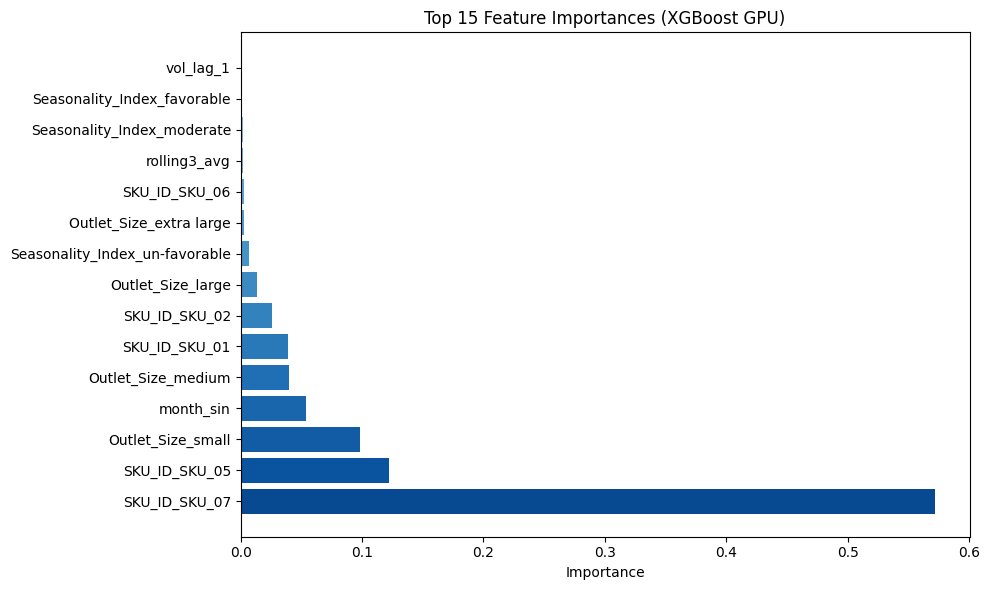

Saved: ../data/figures/feature_importance.png


In [31]:
# Phase 7c: Diagnostics -- Visualizations
# Fix: Manually define FIG_DIR and extract feature importance from the pipeline
FIG_DIR = Path('../data/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Extract feature importance from XGBoost within the pipeline
booster = main_model.named_steps["regressor"]
importances = booster.feature_importances_

# Get feature names from the preprocessor
try:
    # This matches the transformation logic in your preprocessor
    cat_names = main_model.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(cat_features)
    id_names = main_model.named_steps["preprocess"].named_transformers_["id"].get_feature_names_out(id_features)
    all_feat_names = num_features + list(cat_names) + lag_features + list(id_names) + ["month_sin", "month_cos", "Year", "outlet_vol_mean"]
except Exception:
    all_feat_names = [f"feat_{i}" for i in range(len(importances))]

top_k = 15
top_idx = np.argsort(importances)[::-1][:top_k]

# 1. Feature importance plot
plt.figure(figsize=(10, 6))
top_names = [all_feat_names[i] if i < len(all_feat_names) else f"feat_{i}" for i in top_idx]
top_vals = [importances[i] for i in top_idx]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_names)))
plt.barh(range(len(top_names)), top_vals, color=colors[::-1])
plt.yticks(range(len(top_names)), top_names[::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (XGBoost GPU)")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIG_DIR / "feature_importance.png")

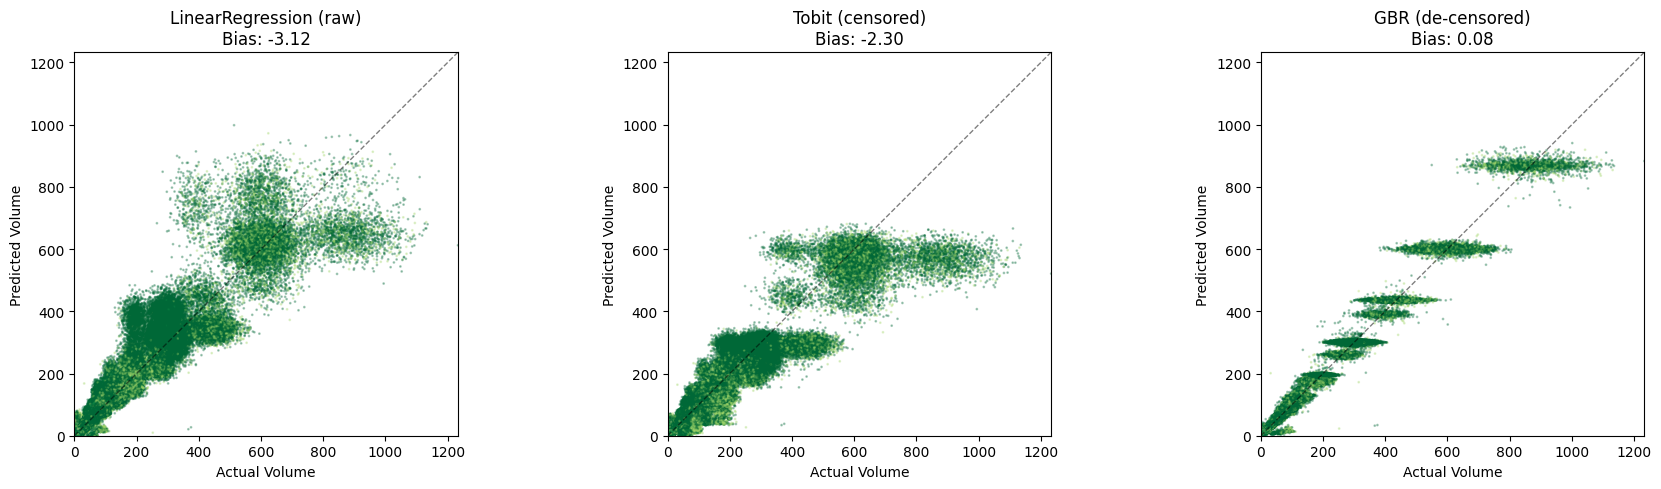

Saved: ../data/figures/actual_vs_predicted.png


In [32]:
# 2. Actual vs Predicted scatter (2025 holdout)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Corrected the mapping and the title string to match actual column names
for ax, (name, pred_col, resid_col, model_name) in zip(axes, [
    ("LR", "pred_lr", "residual_lr", "LinearRegression (raw)"),
    ("Tobit", "pred_tobit", "residual_tobit", "Tobit (censored)"),
    ("GBR", "pred_main", "residual_main", "GBR (de-censored)"),
]):
    ax.scatter(val_results["Volume_Liters"], val_results[pred_col],
               c=val_results["censoring_score"], cmap="RdYlGn_r", alpha=0.3, s=1)
    max_val = max(val_results["Volume_Liters"].max(), val_results[pred_col].max())
    ax.plot([0, max_val], [0, max_val], "k--", alpha=0.5, linewidth=1)
    ax.set_xlabel("Actual Volume")
    ax.set_ylabel("Predicted Volume")
    # Use resid_col directly instead of f-string construction
    ax.set_title(f"{model_name}\nBias: {val_results[resid_col].mean():.2f}")
    ax.set_xlim(0, max_val); ax.set_ylim(0, max_val)
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIG_DIR / "actual_vs_predicted.png")

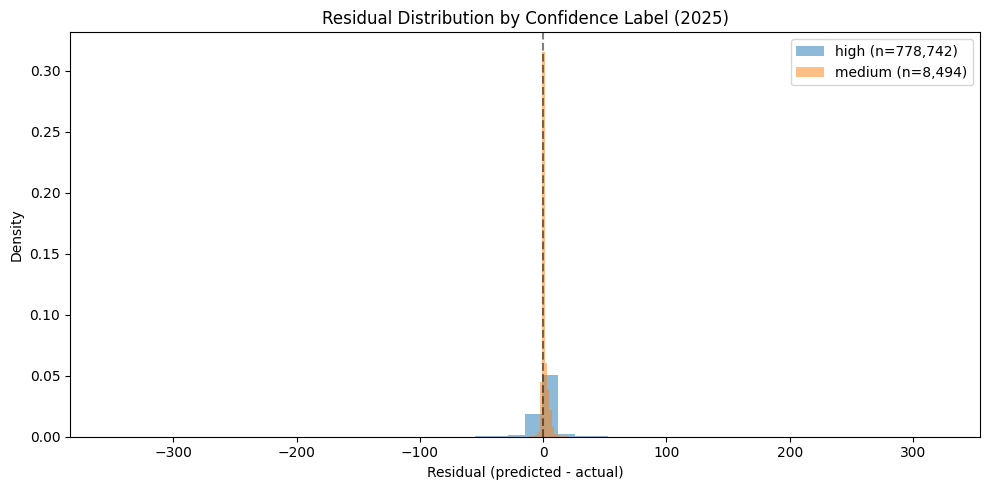

Saved: ../data/figures/residual_distribution.png


In [33]:
# 3. Residual distribution
fig, ax = plt.subplots(figsize=(10, 5))
for label in ["high", "medium", "low"]:
    subset = val_results[val_results["confidence_label"] == label]
    if len(subset) == 0: continue
    ax.hist(subset["residual_main"], bins=50, alpha=0.5,
            label=f"{label} (n={len(subset):,})", density=True)
ax.axvline(0, color="k", linestyle="--", alpha=0.5)
ax.set_xlabel("Residual (predicted - actual)")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution by Confidence Label (2025)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIG_DIR / "residual_distribution.png")

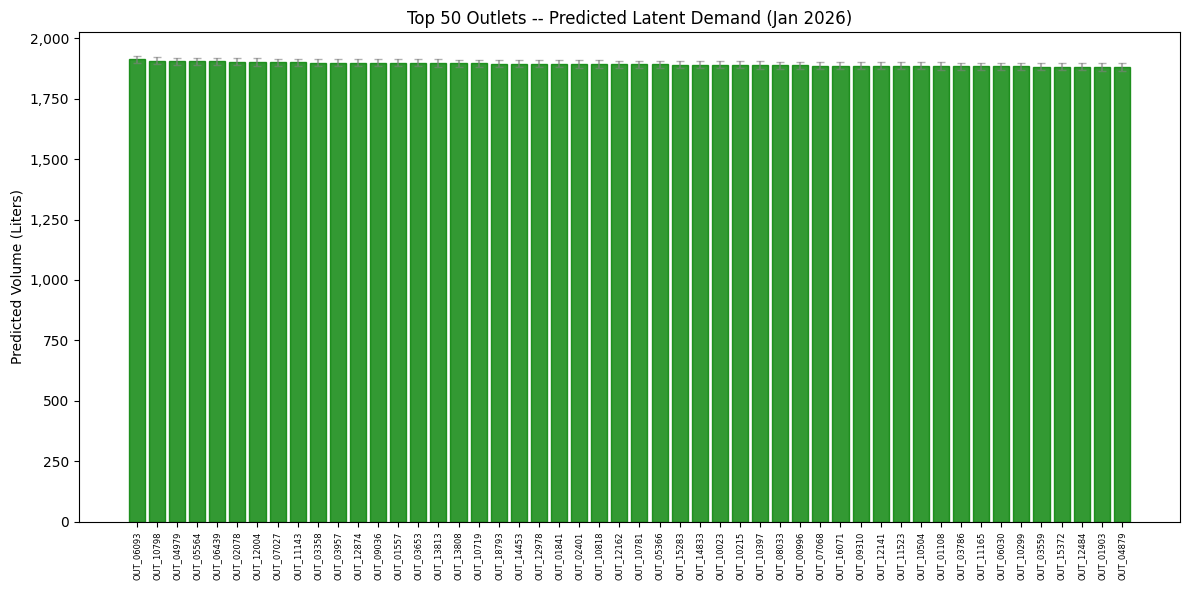

Saved: ../data/figures/top50_predictions.png


In [34]:
# 4. Top 50 outlets
top50 = jan2026_outlet.nlargest(50, "predicted_volume")
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(top50)), top50["predicted_volume"].values, alpha=0.8)
ax.errorbar(range(len(top50)), top50["predicted_volume"].values,
            yerr=[top50["predicted_volume"]-top50["lower_bound"],
                  top50["upper_bound"]-top50["predicted_volume"]],
            fmt="none", capsize=3, color="gray", alpha=0.6)
ax.set_xticks(range(len(top50)))
ax.set_xticklabels(top50["Outlet_ID"].values, rotation=90, fontsize=6)
ax.set_ylabel("Predicted Volume (Liters)")
ax.set_title("Top 50 Outlets -- Predicted Latent Demand (Jan 2026)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, label in zip(bars, top50["confidence_label"]):
    bar.set_color({"high": "green", "medium": "orange", "low": "red"}.get(label, "steelblue"))
plt.tight_layout()
plt.savefig(FIG_DIR / "top50_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIG_DIR / "top50_predictions.png")

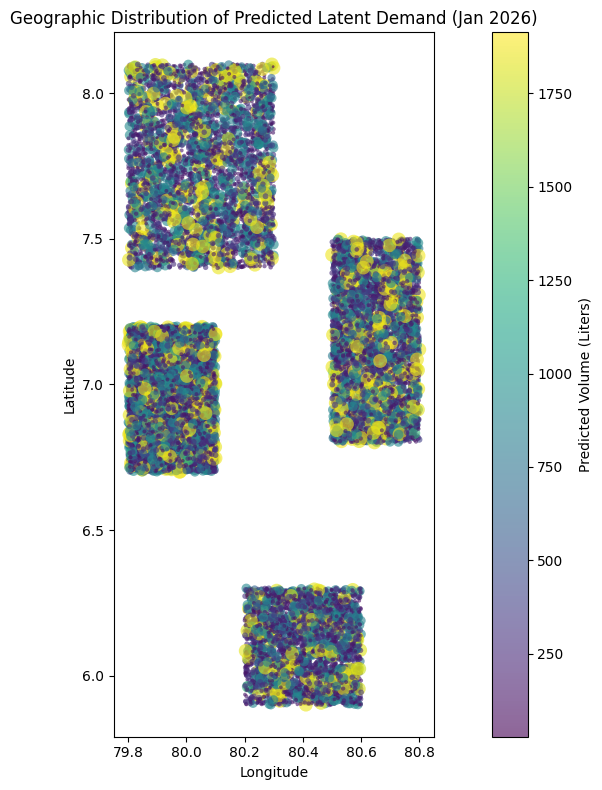

Saved: ../data/figures/prediction_map.png


In [35]:
# 5. Geographic map of predictions
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    jan2026_outlet["Longitude"], jan2026_outlet["Latitude"],
    c=jan2026_outlet["predicted_volume"],
    s=jan2026_outlet["predicted_volume"] / jan2026_outlet["predicted_volume"].max() * 100 + 1,
    cmap="viridis", alpha=0.6, edgecolors="none",
)
plt.colorbar(scatter, ax=ax, label="Predicted Volume (Liters)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution of Predicted Latent Demand (Jan 2026)")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / "prediction_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIG_DIR / "prediction_map.png")

In [36]:
# Final summary
print("=" * 70)
print("  LATENT DEMAND ESTIMATION -- SUMMARY")
print("=" * 70)
print(f"  Target:     Volume_Liters per outlet, January 2026")
print(f"  Outlets:    {len(jan2026_outlet):,}")
print(f"  Total predicted: {jan2026_outlet['predicted_volume'].sum():,.0f} L")
print(f"  Mean per outlet: {jan2026_outlet['predicted_volume'].mean():.1f} L")
print(f"  Median per outlet: {jan2026_outlet['predicted_volume'].median():.1f} L")
print()
print(f"  Best model: GradientBoosting on de-censored series")
print(f"  2025 holdout MAE:  {mae_main:.2f}")
print(f"  2025 holdout RMSE: {rmse_main:.2f}")
print(f"  2025 holdout Bias: {bias_main:.2f}")
print()
print(f"  Censoring detected: {(train_agg['censoring_score'] > 0.2).mean()*100:.1f}% of months flagged")
print(f"  Output: data/models/predictions_jan2026.parquet")
print(f"  Figures: {FIG_DIR}")
print("=" * 70)

  LATENT DEMAND ESTIMATION -- SUMMARY
  Target:     Volume_Liters per outlet, January 2026
  Outlets:    19,960
  Total predicted: 7,500,963 L
  Mean per outlet: 375.8 L
  Median per outlet: 185.8 L

  Best model: GradientBoosting on de-censored series
  2025 holdout MAE:  4.87
  2025 holdout RMSE: 11.52
  2025 holdout Bias: 0.08

  Censoring detected: 6.1% of months flagged
  Output: data/models/predictions_jan2026.parquet
  Figures: ../data/figures
